# 5. Model track C - Random Forest & XGBoost

## 5.1. Thiết lập môi trường

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # notebooks/ -> gốc dự án
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

FIG_DIR = project_root / "figures" / "model_track_c"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix

from src import data, metrics

## 5.2. Nạp dữ liệu đã xử lý

In [3]:
X, y, _ = data.load_processed()
fold = data.load_folds()

## 5.3. Tinh chỉnh (tuning) hyperparameter bằng grid search

**Freeze** param bằng grid search trên **5 fold dùng chung**, chọn tổ hợp có **log loss trung bình thấp nhất** (chỉ số chính). RF: `n_estimators`, `max_depth`; XGB: thêm `learning_rate`.

In [4]:
def grid_search_cv(make_model, param_grid):
    """Quét mọi tổ hợp param trên 5-fold DÙNG CHUNG (data.iter_folds), trả về DataFrame
    gồm các cột param + mean 3 chỉ số (log_loss/accuracy/macro_f1) cho mỗi tổ hợp.

    make_model(params) -> một estimator MỚI (chưa fit) ứng với bộ param đó. Ta chọn tổ
    hợp có log_loss trung bình nhỏ nhất. Dùng chung bộ fold để nhất quán với Track A/B.
    """
    rows = []
    for params in ParameterGrid(param_grid):
        fold_metrics = []
        for f, tr, va in data.iter_folds(fold):
            model = make_model(params)
            model.fit(X.iloc[tr], y.iloc[tr])
            proba = model.predict_proba(X.iloc[va])
            fold_metrics.append(metrics.compute_metrics(y.iloc[va], proba))
        mean = pd.DataFrame(fold_metrics)[metrics.METRIC_NAMES].mean()
        rows.append({**params, **mean.to_dict()})
    return pd.DataFrame(rows)

### 5.3.1. Random Forest — `n_estimators × max_depth`

`max_depth` quá sâu (kể cả `None`) → khớp nhiễu, log loss tăng; `n_estimators` lớn giúp xác suất ổn định nhưng bão hòa dần.

best_rf_params: {'n_estimators': 600, 'max_depth': 14}


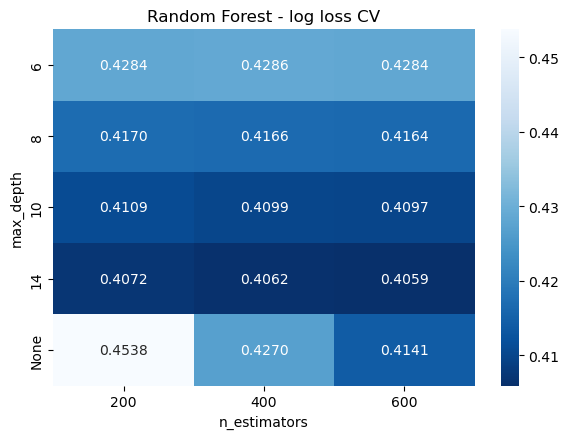

In [5]:
rf_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [6, 8, 10, 14, None],
}

rf_results = grid_search_cv(
    lambda p: RandomForestClassifier(**p, random_state=data.RANDOM_STATE, n_jobs=-1),
    rf_grid,
)

best_row = rf_results.loc[rf_results["log_loss"].idxmin()]
best_rf_params = {
    "n_estimators": int(best_row["n_estimators"]),
    "max_depth": None if pd.isna(best_row["max_depth"]) else int(best_row["max_depth"]),
}
print("best_rf_params:", best_rf_params)

# Heatmap: log loss CV theo (max_depth × n_estimators). max_depth=None hiển thị nhãn "None".
rf_results["max_depth_label"] = rf_results["max_depth"].apply(
    lambda d: "None" if pd.isna(d) else str(int(d)))
depth_order = ["6", "8", "10", "14", "None"]
rf_pivot = (rf_results.pivot(index="max_depth_label", columns="n_estimators", values="log_loss")
            .reindex(depth_order))

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(rf_pivot, annot=True, fmt=".4f", cmap="Blues_r", ax=ax)
ax.set_title("Random Forest - log loss CV")
ax.set_xlabel("n_estimators")
ax.set_ylabel("max_depth")
plt.tight_layout()
fig.savefig(FIG_DIR / "rf_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3.2. XGBoost — `n_estimators × max_depth × learning_rate`

Quét đồng thời 3 param; `learning_rate` cao hoặc `max_depth` sâu dễ overfit. Heatmap cắt tại `learning_rate` tốt nhất.

best_xgb_params: {'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.15}

Top 5 tổ hợp (log loss thấp nhất):
 learning_rate  max_depth  n_estimators  log_loss  accuracy  macro_f1
          0.15          2           400  0.381948  0.849896  0.640039
          0.20          2           400  0.383379  0.850312  0.650838
          0.10          2           400  0.383563  0.850938  0.622040
          0.20          2           200  0.384197  0.851562  0.622767
          0.15          2           200  0.385264  0.850625  0.614963


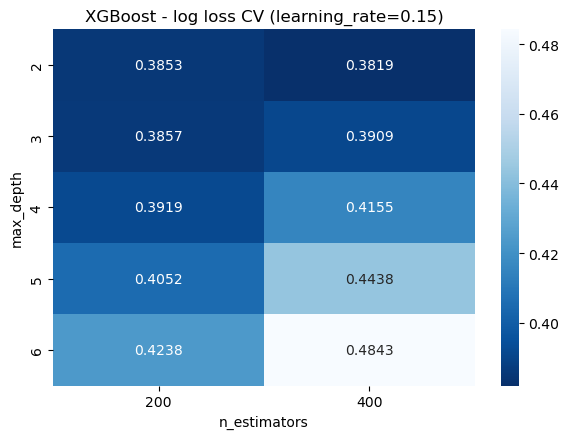

In [6]:
xgb_grid = {
    "n_estimators": [200, 400],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1, 0.15, 0.2],
}

xgb_results = grid_search_cv(
    lambda p: XGBClassifier(**p, random_state=data.RANDOM_STATE, eval_metric="mlogloss", n_jobs=-1),
    xgb_grid,
)

best_row = xgb_results.loc[xgb_results["log_loss"].idxmin()]
best_xgb_params = {
    "n_estimators": int(best_row["n_estimators"]),
    "max_depth": int(best_row["max_depth"]),
    "learning_rate": float(best_row["learning_rate"]),
}
print("best_xgb_params:", best_xgb_params)
print("\nTop 5 tổ hợp (log loss thấp nhất):")
print(xgb_results.sort_values("log_loss").head().to_string(index=False))

# Heatmap tại learning_rate tốt nhất: log loss CV theo (max_depth × n_estimators)
best_lr = best_xgb_params["learning_rate"]
xgb_pivot = (xgb_results[xgb_results["learning_rate"] == best_lr]
             .pivot(index="max_depth", columns="n_estimators", values="log_loss"))

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(xgb_pivot, annot=True, fmt=".4f", cmap="Blues_r", ax=ax)
ax.set_title(f"XGBoost - log loss CV (learning_rate={best_lr})")
ax.set_xlabel("n_estimators")
ax.set_ylabel("max_depth")
plt.tight_layout()
fig.savefig(FIG_DIR / "xgb_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.4. Khai báo mô hình (đã freeze)

Dùng `best_rf_params`, `best_xgb_params` từ mục 5.3. `results/scores_track_c.csv` sinh bên dưới là **bản cuối** cho kiểm định HEP-13/14/15 — **đóng HEP-23**.

In [7]:
models = {
    "Random Forest": RandomForestClassifier(**best_rf_params, random_state=data.RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(**best_xgb_params, random_state=data.RANDOM_STATE, eval_metric="mlogloss", n_jobs=-1),
}

## 5.5. Huấn luyện & đánh giá bằng Cross-Validation

Mỗi fold `clone(base_model)` train lại từ đầu; thu dự đoán out-of-fold (cho confusion matrix) và `feature_importances_` (mục sau).

In [8]:
rows = []
oof_true = {name: [] for name in models}
oof_pred = {name: [] for name in models}
feature_importances = {name: [] for name in models}

for f, tr, va in data.iter_folds(fold):
    for name, base_model in models.items():
        model = clone(base_model)
        model.fit(X.iloc[tr], y.iloc[tr])
        proba = model.predict_proba(X.iloc[va])

        rows.append({"model": name, "fold": f, **metrics.compute_metrics(y.iloc[va], proba)})
        oof_true[name].append(y.iloc[va])
        oof_pred[name].append(proba.argmax(axis=1))
        
        if hasattr(model, "feature_importances_"):
            feature_importances[name].append(model.feature_importances_)

scores = pd.DataFrame(rows)
scores.head()

,model,fold,log_loss,accuracy,macro_f1
0,Random Forest,0,0.407216,0.846354,0.574506
1,XGBoost,0,0.389471,0.848437,0.631331
2,Random Forest,1,0.400313,0.859896,0.576349
3,XGBoost,1,0.372344,0.860938,0.609400
4,Random Forest,2,0.406624,0.843750,0.559419


## 5.6. Lưu kết quả CV

In [9]:
scores.to_csv("../results/scores_track_c.csv", index=False)
scores

,model,fold,log_loss,accuracy,macro_f1
0,Random Forest,0,0.407216,0.846354,0.574506
1,XGBoost,0,0.389471,0.848437,0.631331
2,Random Forest,1,0.400313,0.859896,0.576349
3,XGBoost,1,0.372344,0.860938,0.609400
4,Random Forest,2,0.406624,0.843750,0.559419
5,XGBoost,2,0.381739,0.847917,0.670613
6,Random Forest,3,0.400941,0.842708,0.570514
7,XGBoost,3,0.377374,0.846354,0.612574
8,Random Forest,4,0.414431,0.845313,0.561737
9,XGBoost,4,0.388812,0.845833,0.676278


## 5.7. Bảng tổng hợp kết quả (mean ± std)

In [10]:
summary = metrics.summarize_scores(scores)
summary

log_loss            accuracy            macro_f1          
                   mean       std      mean       std      mean       std
model                                                                    
Random Forest  0.405905  0.005719  0.847604  0.007013  0.568505  0.007582
XGBoost        0.381948  0.007364  0.849896  0.006265  0.640039  0.031690

## 5.8. Confusion Matrix (Out-of-Fold)

Gộp dự đoán out-of-fold 5 fold, chuẩn hóa theo hàng (`normalize="true"`).

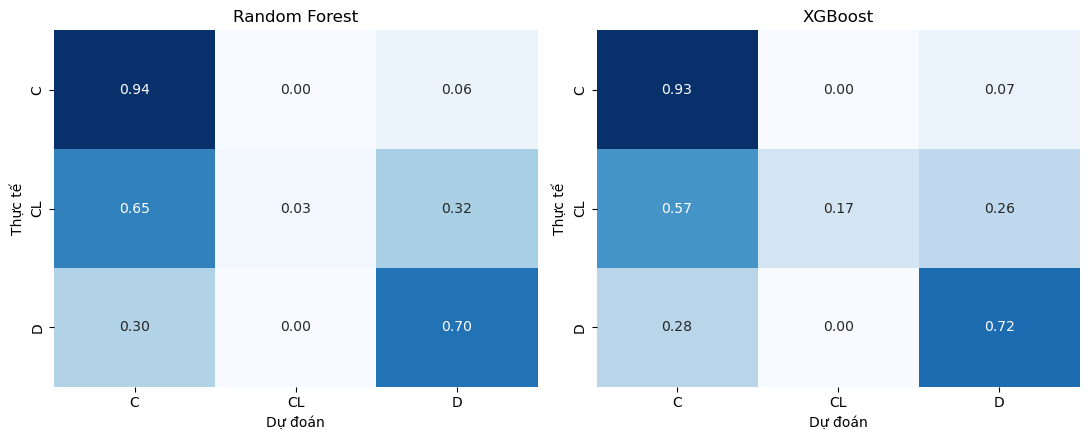

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, models):
    y_true_all = pd.concat(oof_true[name])
    y_pred_all = np.concatenate(oof_pred[name])
    cm = confusion_matrix(y_true_all, y_pred_all, labels=data.LABELS, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=data.CLASS_ORDER, yticklabels=data.CLASS_ORDER, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
plt.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.9. Độ quan trọng đặc trưng (Feature Importance)

Top 15 đặc trưng, trung bình qua 5 fold.

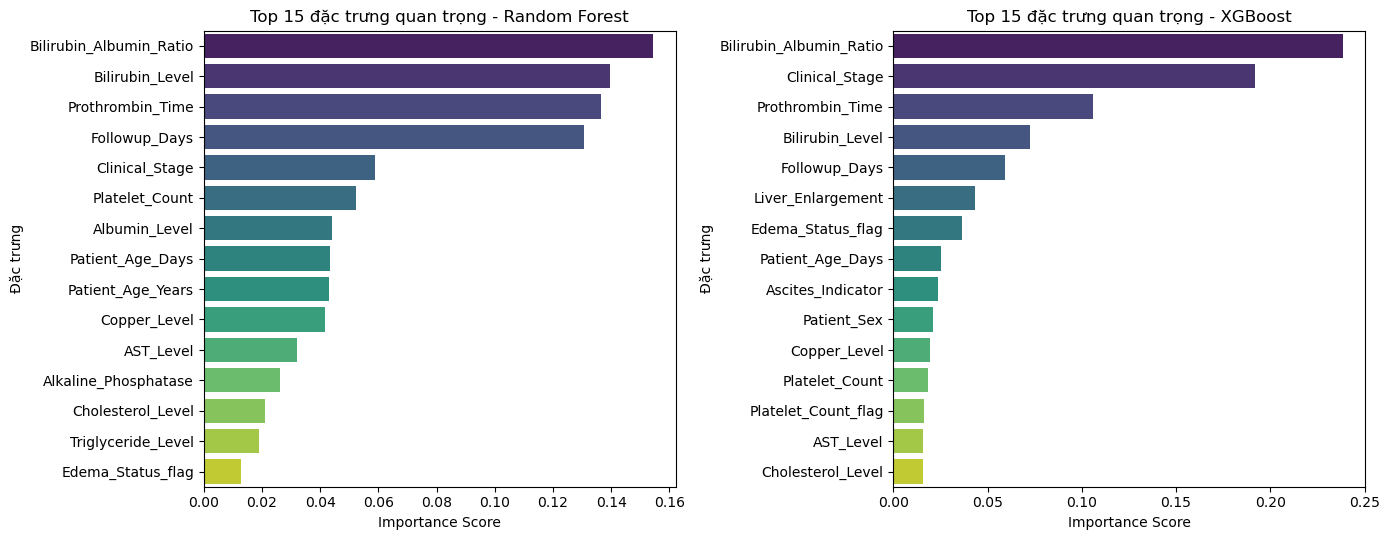

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
feature_names = X.columns

for ax, name in zip(axes, models):
    mean_imp = np.mean(feature_importances[name], axis=0)
    imp_df = pd.DataFrame({"feature": feature_names, "importance": mean_imp}).sort_values("importance", ascending=False).head(15)
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, hue="feature", legend=False, palette="viridis")
    ax.set_title(f"Top 15 đặc trưng quan trọng - {name}")
    ax.set_xlabel("Importance Score")
    ax.set_ylabel("Đặc trưng")

plt.tight_layout()
fig.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.10. So sánh trực quan 2 mô hình

Cột so sánh trung bình 3 chỉ số (log loss, accuracy, macro-F1) qua 5 fold.

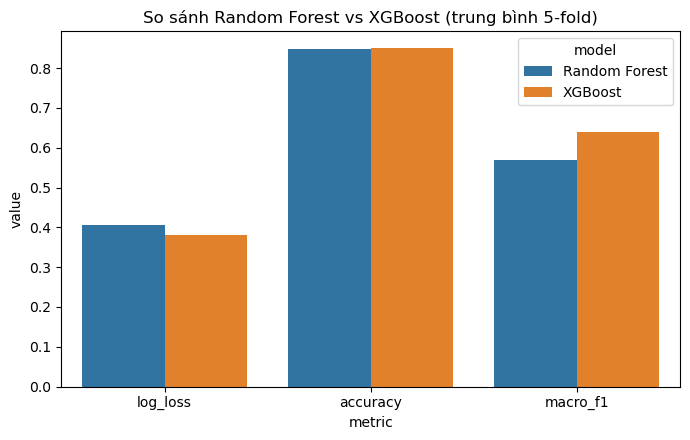

In [13]:
plot_df = summary.xs("mean", axis=1, level=1).reset_index()
plot_df = plot_df.melt(id_vars="model", var_name="metric", value_name="value")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=plot_df, x="metric", y="value", hue="model", ax=ax)
ax.set_title("So sánh Random Forest vs XGBoost (trung bình 5-fold)")
plt.tight_layout()
fig.savefig(FIG_DIR / "metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.11. Nhận xét

**Param đã freeze:** RF `n_estimators=600, max_depth=14`; XGB `n_estimators=400, max_depth=2, learning_rate=0.15`. Tune giảm rõ log loss so với mặc định (RF 0.521 → **0.406**; XGB 0.432 → **0.382**). Vùng log loss thấp của XGB rất phẳng và ưu tiên cây nông → tránh overfit khi dữ liệu ít.

**XGBoost > Random Forest** ở cả 3 chỉ số:
- Log loss: **0.382 ± 0.007** vs 0.406 ± 0.006 (XGB tối ưu trực tiếp `mlogloss`).
- Accuracy: **0.850** vs 0.848 (sát nhau).
- Macro-F1: **0.640** vs 0.569 — XGB xử lý lớp hiếm `CL` tốt hơn nhờ boosting.

**Feature importance:** cả hai đều xếp nhóm chỉ số gan (`Bilirubin`, `Prothrombin_Time`, `Copper_Level`, `Albumin`, `AST_Level`) lên top - trùng tín hiệu Track A/B.

**Kết luận:** XGBoost tốt nhất ở log loss (chỉ số chính). Model + hyperparameter đã freeze; `scores_track_c.csv` là bản cuối cho HEP-13/14/15 - **đóng HEP-23**.